Load our dataset and prepare minibatches

In [60]:
print('start')
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/My Drive/Cybr486Project/Dataset'

print('normalize transform starting')
normalize_transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))]
)
dataset = torchvision.datasets.ImageFolder(data_dir, transform=normalize_transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
print('normalize transform ending')
print('load datasets start')
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
test_dataset.class_to_idx = dataset.class_to_idx
print('load datasets end')

start
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
normalize transform starting
normalize transform ending
load datasets start
load datasets end


Visualize and analyze our data

******
VISUALIZE DATA SET


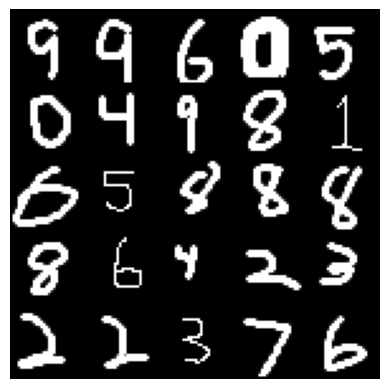

*******
ANALYZE DATASET


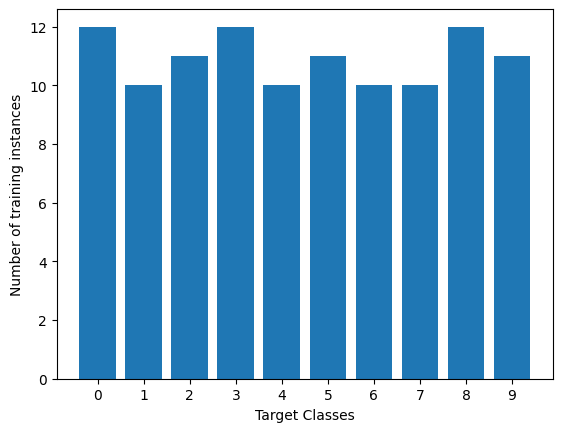

In [61]:
#prepare minibatches
batch_size = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

#visualization
print("******\nVISUALIZE DATA SET")
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()



#analyze dataset
print("*******\nANALYZE DATASET")
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

Build our model

In [62]:
class CNN(torch.nn.Module):
    def __init__(self,num_features):
        super().__init__()
        out1_base = 8
        out2_base = 16
        out1_channels = num_features*out1_base+out1_base
        out2_channels = num_features*out2_base+out2_base
        if num_features == 4:
            out1_channels += out1_base
            out2_channels += out2_base
        elif num_features == 5:
            out1_channels += out1_base*2
            out2_channels += out2_base*2

        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3, out_channels=out1_channels,
                        kernel_size=5, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=out1_channels, out_channels=out2_channels,
                        kernel_size=5, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Flatten(),
            torch.nn.LazyLinear(256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 10)
        )
    def forward(self,x):
        return self.model(x)

In [40]:
#gpu acceleration
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


Train our model



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.3070592880249023
Epoch 2/20: Training loss = 2.2587485313415527
Epoch 3/20: Training loss = 2.21518874168396
Epoch 4/20: Training loss = 2.1619741916656494
Epoch 5/20: Training loss = 2.0965123176574707
Epoch 6/20: Training loss = 2.015824317932129
Epoch 7/20: Training loss = 1.9193028211593628
Epoch 8/20: Training loss = 1.8059016466140747
Epoch 9/20: Training loss = 1.6757630109786987
Epoch 10/20: Training loss = 1.5307384729385376
Epoch 11/20: Training loss = 1.3744601011276245
Epoch 12/20: Training loss = 1.212988018989563
Epoch 13/20: Training loss = 1.0532212257385254
Epoch 14/20: Training loss = 0.9030724763870239
Epoch 15/20: Training loss = 0.7702659368515015
Epoch 16/20: Training loss = 0.6580716967582703
Epoch 17/20: Training loss = 0.5650065541267395
Epoch 18/20: Training loss = 0.48742949962615967
Epoch 19/20: Training loss = 0.42136847972869873
Epoch 20/20: Training loss = 0.3638840317726

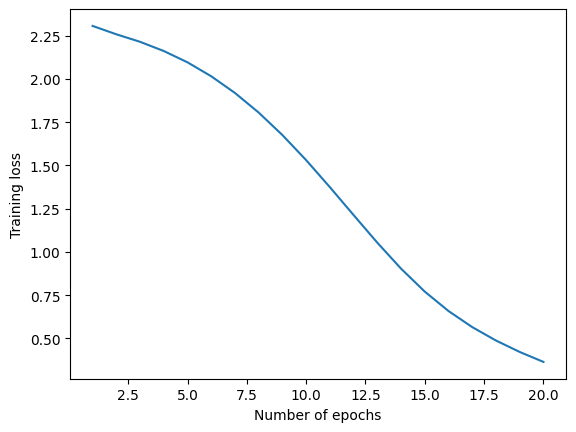

channels: 8 Test set accuracy = 67.85714285714286 %


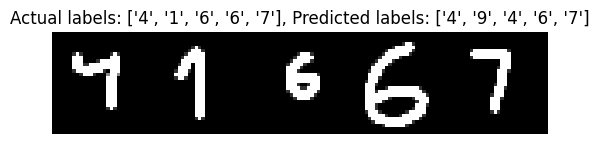



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.3089241981506348
Epoch 2/20: Training loss = 2.2382657527923584
Epoch 3/20: Training loss = 2.1564688682556152
Epoch 4/20: Training loss = 2.0372114181518555
Epoch 5/20: Training loss = 1.881906270980835
Epoch 6/20: Training loss = 1.689672589302063
Epoch 7/20: Training loss = 1.4662359952926636
Epoch 8/20: Training loss = 1.2215383052825928
Epoch 9/20: Training loss = 0.9795752763748169
Epoch 10/20: Training loss = 0.7673007845878601
Epoch 11/20: Training loss = 0.6003241539001465
Epoch 12/20: Training loss = 0.4779254198074341
Epoch 13/20: Training loss = 0.39075329899787903
Epoch 14/20: Training loss = 0.32216429710388184
Epoch 15/20: Training loss = 0.25305095314979553
Epoch 16/20: Training loss = 0.1978091150522232
Epoch 17/20: Training loss = 0.1541142612695694
Epoch 18/20: Training loss = 0.10979185253381729
Epoch 19/20: Training loss = 0.08510494977235794
Epoch 20/20: Training loss = 0.06464546

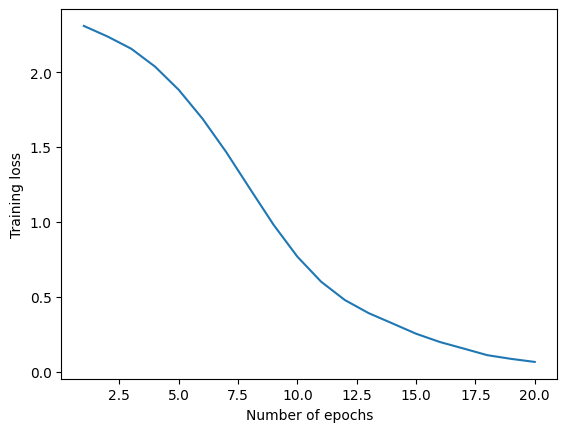

channels: 16 Test set accuracy = 64.28571428571429 %


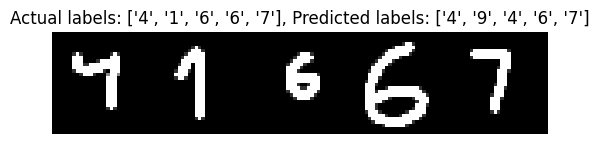



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.3034329414367676
Epoch 2/20: Training loss = 2.1887738704681396
Epoch 3/20: Training loss = 2.0159521102905273
Epoch 4/20: Training loss = 1.793297290802002
Epoch 5/20: Training loss = 1.52006995677948
Epoch 6/20: Training loss = 1.2233386039733887
Epoch 7/20: Training loss = 0.9409420490264893
Epoch 8/20: Training loss = 0.7138333320617676
Epoch 9/20: Training loss = 0.566206693649292
Epoch 10/20: Training loss = 0.48685550689697266
Epoch 11/20: Training loss = 0.3807293176651001
Epoch 12/20: Training loss = 0.31735020875930786
Epoch 13/20: Training loss = 0.24277187883853912
Epoch 14/20: Training loss = 0.1989447921514511
Epoch 15/20: Training loss = 0.13947896659374237
Epoch 16/20: Training loss = 0.1215205043554306
Epoch 17/20: Training loss = 0.08097568154335022
Epoch 18/20: Training loss = 0.06555540859699249
Epoch 19/20: Training loss = 0.0506671778857708
Epoch 20/20: Training loss = 0.036661103

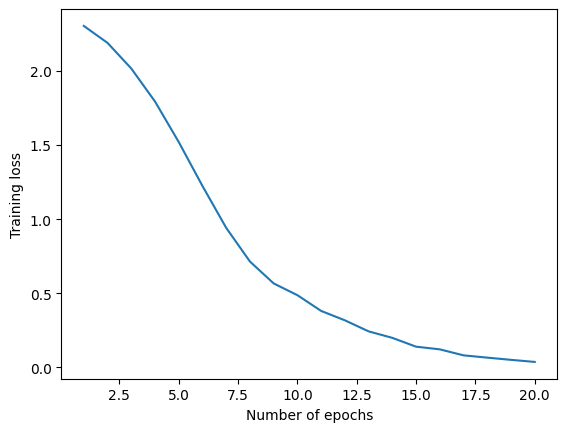

channels: 24 Test set accuracy = 64.28571428571429 %


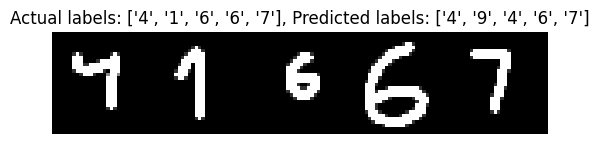



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.301877021789551
Epoch 2/20: Training loss = 2.214038610458374
Epoch 3/20: Training loss = 2.055736780166626
Epoch 4/20: Training loss = 1.820292592048645
Epoch 5/20: Training loss = 1.5188621282577515
Epoch 6/20: Training loss = 1.1828798055648804
Epoch 7/20: Training loss = 0.8821843862533569
Epoch 8/20: Training loss = 0.6406083703041077
Epoch 9/20: Training loss = 0.4999789893627167
Epoch 10/20: Training loss = 0.46624693274497986
Epoch 11/20: Training loss = 0.30936527252197266
Epoch 12/20: Training loss = 0.29978081583976746
Epoch 13/20: Training loss = 0.20904137194156647
Epoch 14/20: Training loss = 0.16125740110874176
Epoch 15/20: Training loss = 0.12369944900274277
Epoch 16/20: Training loss = 0.09004697948694229
Epoch 17/20: Training loss = 0.06875026226043701
Epoch 18/20: Training loss = 0.06307627260684967
Epoch 19/20: Training loss = 0.0427081398665905
Epoch 20/20: Training loss = 0.027498

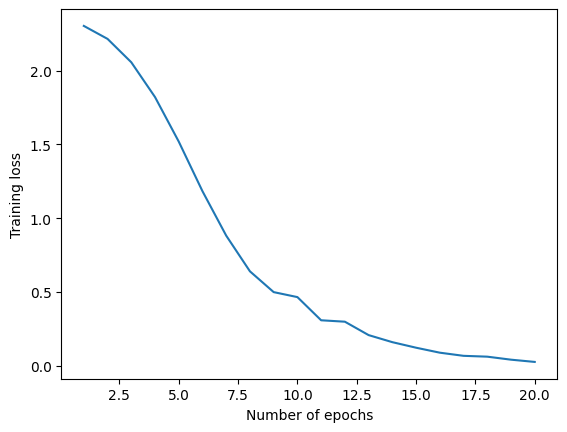

channels: 32 Test set accuracy = 67.85714285714286 %


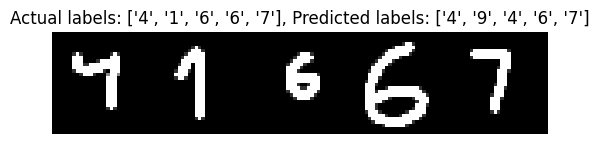



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.3061511516571045
Epoch 2/20: Training loss = 2.178372383117676
Epoch 3/20: Training loss = 1.9736543893814087
Epoch 4/20: Training loss = 1.619011402130127
Epoch 5/20: Training loss = 1.2571039199829102
Epoch 6/20: Training loss = 0.9517520070075989
Epoch 7/20: Training loss = 0.6747857332229614
Epoch 8/20: Training loss = 0.592143177986145
Epoch 9/20: Training loss = 0.4058454930782318
Epoch 10/20: Training loss = 0.3622366487979889
Epoch 11/20: Training loss = 0.2975090742111206
Epoch 12/20: Training loss = 0.20488204061985016
Epoch 13/20: Training loss = 0.16038015484809875
Epoch 14/20: Training loss = 0.13354946672916412
Epoch 15/20: Training loss = 0.07376335561275482
Epoch 16/20: Training loss = 0.07188254594802856
Epoch 17/20: Training loss = 0.04869972914457321
Epoch 18/20: Training loss = 0.03297865763306618
Epoch 19/20: Training loss = 0.030000336468219757
Epoch 20/20: Training loss = 0.02806

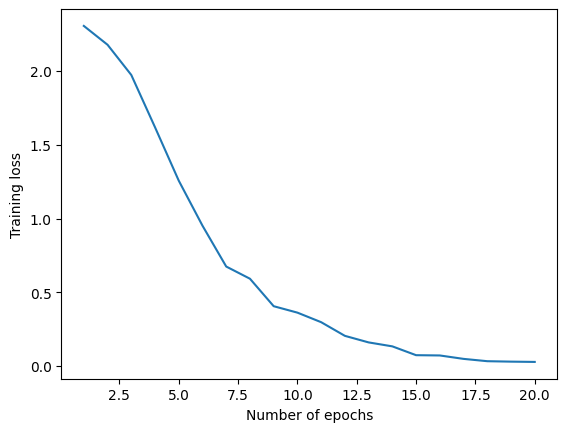

channels: 48 Test set accuracy = 71.42857142857143 %


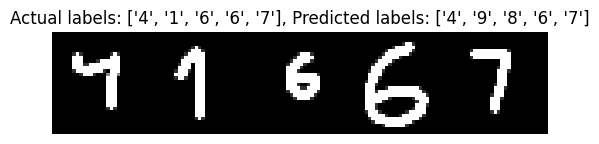



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 2.3019542694091797
Epoch 2/20: Training loss = 2.2002108097076416
Epoch 3/20: Training loss = 1.9983562231063843
Epoch 4/20: Training loss = 1.5961889028549194
Epoch 5/20: Training loss = 1.140571117401123
Epoch 6/20: Training loss = 0.9314140677452087
Epoch 7/20: Training loss = 0.7967614531517029
Epoch 8/20: Training loss = 0.7644637823104858
Epoch 9/20: Training loss = 0.6106162071228027
Epoch 10/20: Training loss = 0.37474462389945984
Epoch 11/20: Training loss = 0.3924560844898224
Epoch 12/20: Training loss = 0.2679572105407715
Epoch 13/20: Training loss = 0.20428432524204254
Epoch 14/20: Training loss = 0.19632861018180847
Epoch 15/20: Training loss = 0.17650432884693146
Epoch 16/20: Training loss = 0.13812008500099182
Epoch 17/20: Training loss = 0.0979846864938736
Epoch 18/20: Training loss = 0.07279815524816513
Epoch 19/20: Training loss = 0.056873880326747894
Epoch 20/20: Training loss = 0.0457

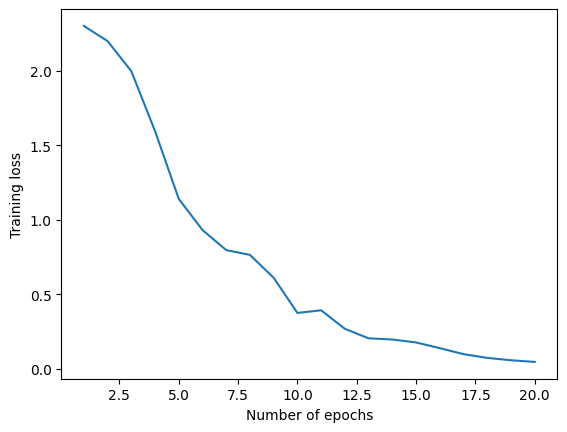

channels: 64 Test set accuracy = 67.85714285714286 %


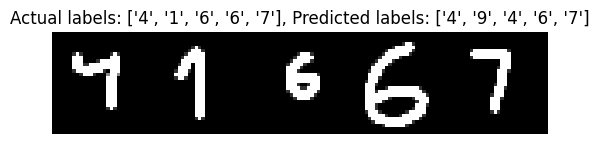

In [63]:
num_epochs = 20
learning_rate = 0.001
weight_decay = 0.01
features = 6
for i in range(features):
    model = CNN(i).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay)


    #train
    print("\n\n*****************\nTRAINING STARTING\n****************")
    train_loss_list = []
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
        train_loss = 0
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss_list.append(train_loss / len(train_loader))
        print(f"Training loss = {train_loss_list[-1]}")
    print("\n\n*****************\nTRAINING DONE\n****************")
    plt.plot(range(1, num_epochs + 1), train_loss_list)
    plt.xlabel("Number of epochs")
    plt.ylabel("Training loss")
    plt.show()

    test_acc = 0
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            y_true = labels.to(device)
            outputs = model(images)
            _, y_pred = torch.max(outputs.data, 1)
            test_acc += (y_pred == y_true).sum().item()

    num = (i*8)+8
    if i > 3:
        num += 8
    if i > 4:
        num += 8
    print(f"channels: {num} Test set accuracy = {100 * test_acc / len(test_dataset)} %")
    num_images = 5
    y_true_name = [names[y_true[idx]] for idx in range(num_images)]
    y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
    title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

    plt.imshow(np.transpose(torchvision.utils.make_grid(
        images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

Test our model